# Phase 0 — Baselines: what must every model beat?

**Before any model: how well do naive, points-only predictors rank next-gameweek returns?**

_Read-only benchmark — Phase 0 of [docs/predictive-layer-plan.md](../../docs/predictive-layer-plan.md). No model here; this fixes the floor every later model is measured against._
Population: `minutes > 0`, **DGW excluded**, evaluate GW > 3; expanding-window walk-forward, leakage-checked.

> **How to read.** Each baseline predicts a player's points from that player's **strictly-prior** gameweeks only (leakage-safe). We score **ranking**, not exact points, because FPL is won by ranking players and the target is zero-inflated/right-skewed. Headline metrics: per-GW **Spearman** (pooled and per-position), tie-aware **precision@k**, **NDCG@k**; MAE is a secondary sanity number; RMSE is omitted (haul-dominated).

> **Conditional on appearance.** Metrics cover players who *actually featured* — availability is treated as known. This is *ranking given the player played*, a valid sub-problem, **not** end-to-end forecast accuracy. Predicting who plays is the availability family's job.

## Setup
> Load the mart, apply the population filter, and pull the two harness views: pooled and per-position. All numbers come from `model.eval` — the notebook only renders them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from model.eval import walk_forward_baselines, walk_forward_by_position
from model.eval.walkforward import POSITIONS

BASELINE_COLOUR = {
    'expanding season avg': '#1f77b4', 'rolling avg (5)': '#2ca02c', 'rolling avg (3)': '#98df8a',
    'last-GW points': '#ff7f0e', 'position mean (sanity floor)': '#bdbdbd',
}

try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f'Rebuilding mart ({type(err).__name__})...')
    run_pipeline(force=True)
    loaded = load_mart()
mart = loaded.mart

pooled = walk_forward_baselines(mart)
by_pos = walk_forward_by_position(mart)
print(f'Study range: GW 1 - {loaded.data_cutoff_gw} | minutes > 0 | DGW excluded | common eval n = {int(pooled["n"].iloc[0]):,}')

Study range: GW 1 - 38 | minutes > 0 | DGW excluded | common eval n = 8,728


## (a) Pooled benchmark — which naive predictor ranks best?
> `spearman_pos` (within-position) is the decision-relevant number; `spearman_mean` (pooled) sits higher because it gets free credit from position-level differences. The **season average wins** — a player's cumulative level is the strongest simple signal (*level persists*), while chasing last week (*last-GW*) is worst (*deviations mean-revert*). The identity-free **position mean ranks at chance**, so the signal is player identity.

,spearman_mean,spearman_pos,precision_at_k,ndcg_at_k,mae,n,coverage
baseline,,,,,,,
expanding season avg,0.2454,0.2049,0.1712,0.3767,2.1931,8728,0.984
rolling avg (5),0.2174,0.2016,0.1530,0.3507,2.2835,8728,0.849
rolling avg (3),0.1955,0.1765,0.1485,0.3352,2.3778,8728,0.940
last-GW points,0.1743,0.1632,0.1258,0.3131,2.7030,8728,0.984
position mean (sanity floor),0.0110,NaN,0.0803,0.2875,2.2287,8728,1.000


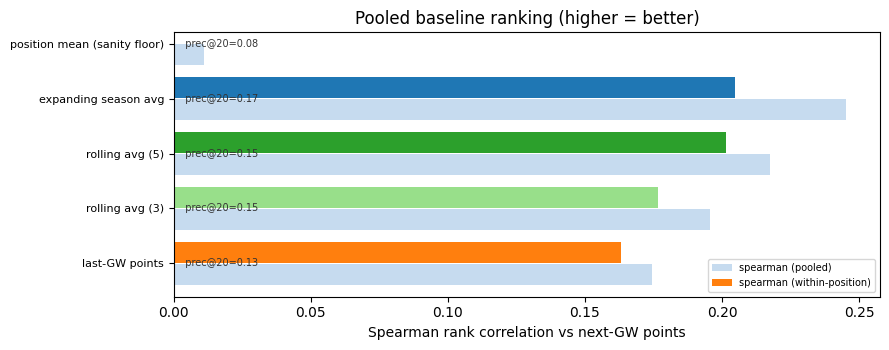

In [2]:
display(pooled.round(4))

order = pooled.sort_values('spearman_pos').index
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(y - 0.2, pooled.loc[order, 'spearman_mean'], height=0.38, color='#c6dbef', label='spearman (pooled)')
ax.barh(y + 0.2, pooled.loc[order, 'spearman_pos'], height=0.38,
        color=[BASELINE_COLOUR[b] for b in order], label='spearman (within-position)')
for i, b in enumerate(order):
    p = pooled.loc[b, 'precision_at_k']
    ax.text(0.002, i, f"  prec@20={p:.2f}", va='center', fontsize=7, color='#333')
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Spearman rank correlation vs next-GW points'); ax.axvline(0, color='k', lw=0.5)
ax.set_title('Pooled baseline ranking (higher = better)'); ax.legend(fontsize=7, loc='lower right')
plt.tight_layout(); plt.show()

## (b) Per-position benchmark — the real bar to beat
> Squads fill under position quotas, so ranking that matters is *within* position, and the pooled number hides a ~5x spread. **GK is near chance** (clean-sheet/fixture driven, not player persistence — echoing the diagnostic layer's GK abstentions). **MID and FWD are the rankable positions**; FWD is the one place recent form (**rolling-5**) beats season class. These per-position bars — not the pooled number — gate Phase 1.

spearman  precision_at_k   k  n_gw
position baseline                                                        
GK       rolling avg (5)                 0.0619          0.2803   4    33
         last-GW points                  0.0352          0.2576   4    33
         rolling avg (3)                 0.0349          0.2879   4    33
         expanding season avg            0.0236          0.3258   4    33
         position mean (sanity floor)       NaN             NaN   4    33
DEF      expanding season avg            0.1671          0.3500  20    33
         rolling avg (5)                 0.1312          0.3242  20    33
         rolling avg (3)                 0.1015          0.3076  20    33
         last-GW points                  0.0829          0.2788  20    33
         position mean (sanity floor)       NaN             NaN  20    33
MID      expanding season avg            0.3114          0.2985  20    33
         rolling avg (5)                 0.2793          0.2864  20    33
         rolling avg (3)                 0.2691          0.2515  20    33
         last-GW points                  0.2450          0.2394  20    33
         position mean (sanity floor)       NaN             NaN  20    33
FWD      rolling avg (5)                 0.3339          0.4811   8    33
         expanding season avg            0.3175          0.4811   8    33
         rolling avg (3)                 0.3005          0.4659   8    33
         last-GW points                  0.2895          0.4659   8    33
         position mean (sanity floor)       NaN             NaN   8    33

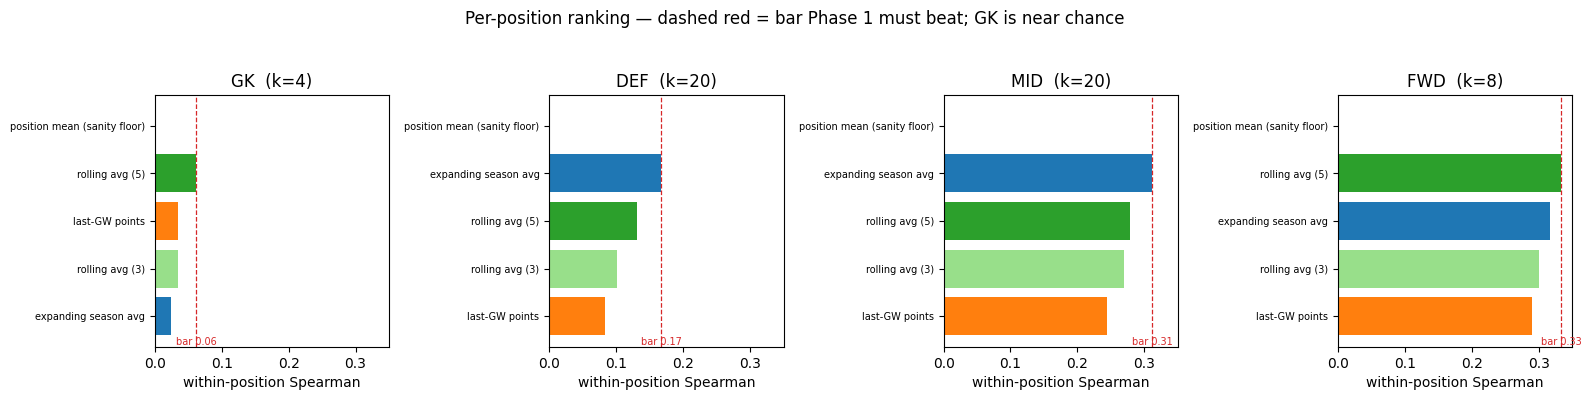

In [3]:
display(by_pos.round(4))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
for ax, pos in zip(axes, POSITIONS):
    sub = by_pos.xs(pos, level='position').sort_values('spearman')
    labels = sub.index
    yy = np.arange(len(labels))
    ax.barh(yy, sub['spearman'].fillna(0.0), color=[BASELINE_COLOUR[b] for b in labels])
    best = sub['spearman'].max()
    ax.axvline(best, color='#d62728', ls='--', lw=0.9)
    ax.text(best, -0.6, f'bar {best:.2f}', color='#d62728', fontsize=7, ha='center')
    ax.set_yticks(yy); ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f'{pos}  (k={int(sub["k"].iloc[0])})'); ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('within-position Spearman')
fig.suptitle('Per-position ranking — dashed red = bar Phase 1 must beat; GK is near chance', y=1.04)
plt.tight_layout(); plt.show()

## Summary — the bars Phase 1 must beat

| position | bar (within-position Spearman) | read |
|---|---|---|
| GK | ~0.06 | near chance — history barely ranks keepers |
| DEF | 0.17 | middling |
| MID | 0.31 | rankable |
| FWD | 0.33 | most rankable; rolling-5 > season-avg |

**What it establishes.** *Level persists* (season avg best), *deviations mean-revert* (last-GW worst, smoothing helps), *identity dominates* (position-only ranks at chance — corroborates Q1b). The frozen numbers live in [docs/studies/results/predictive-phase0-baselines.md](../../docs/studies/results/predictive-phase0-baselines.md).

**Gate.** A Phase-1 model earns promotion only by beating these **per-position** bars on this same walk-forward harness — not the pooled number, which a model can inflate via easy position-level structure.